# Basics of Calculus

This notes is based on teaching video from Prof. Gilbert Strang, Highlight of Calculus. We expanded the explanation to include more details step by step.

### Import Libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


## Distance and Speed Function

### Revision of Speed, Distance and Time

To compute the speed, distance and time of a car moving, we have the following formula:

$$distance = speed \times time$$
$$speed = \frac{distance}{time}$$
$$time = \frac{distance}{speed}$$

$$f = distance$$
$$s = speed$$
$$t = time$$

> We use f for distance as we have specific use for d


So if we have travel on 20km/h, then distance traveled after 2 hour will be $f = st = 20 \times 2 = 40km$

If total distance traveled is 80km for 4 hour then the speed will be $s = \frac{f}{t} = \frac{80}{4} = 20km/h$

If total distance traveled is 60km and the speed is 20km/h. Then the time spent will be $t = \frac{distance}{speed} = \frac{60}{20} = 3h$.

### Measuring Distance and Speed


Let consider a car driving at 20km/h ($s = 20 km/h$) throughout the journey.
Thus
$$f = 20 \times t = 20t$$

The following chart show the relationship between distance and time.

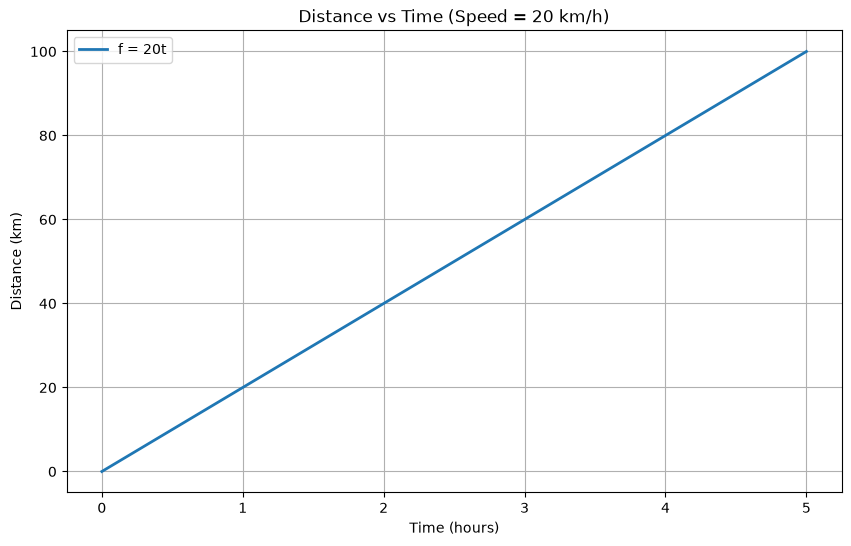

In [3]:
# Time in hours
time = np.linspace(0, 5, 30)
speed = 20  # km/h
distance = speed * time

# Plot distance vs time
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=2)
plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed = 20 km/h)')
plt.legend(['f = 20t'])
plt.grid(True)
plt.show()

The following chart shows the speed vs time. Since speed is constant, we have a straight line graph.

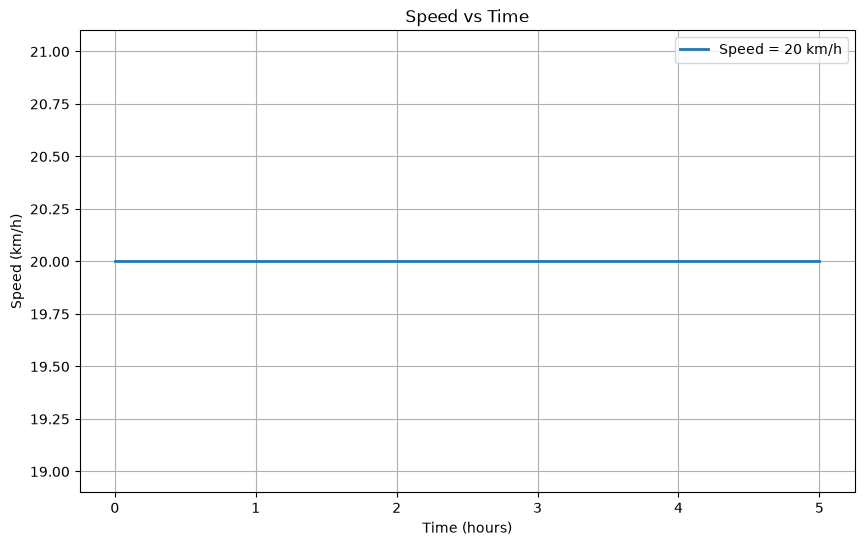

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(time, [speed] * len(time), linewidth=2, label='Speed')
plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time')
plt.legend(['Speed = 20 km/h'])
plt.grid(True)
plt.show()

### Using Slope and Area

Now let's examine the distance vs time graph. How can we determine the speed? We can get the speed of the car from the slope.

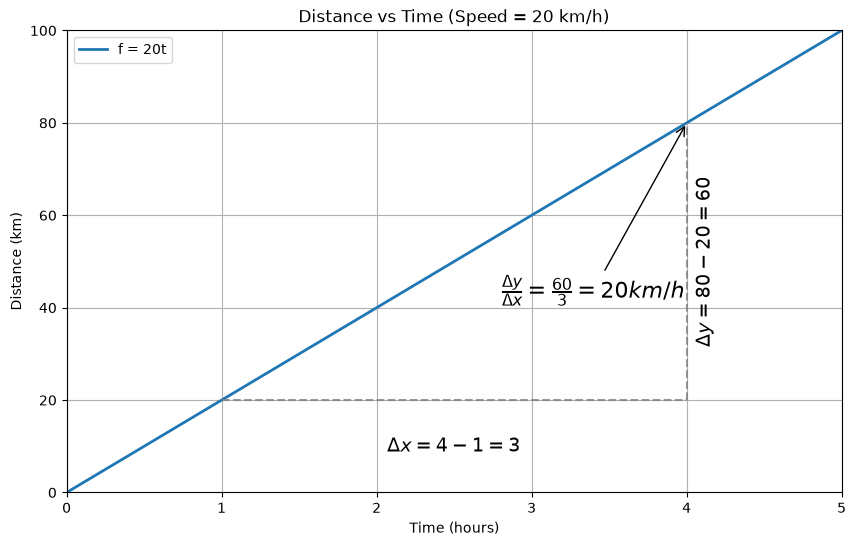

In [5]:
# Time in hours
time = np.linspace(0, 5, 30)
speed = 20  # km/h
distance = speed * time

# Plot distance vs time
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=2, label='f = 20t')

# Highlight the slope as change in y over change in x
x1, x2 = 1, 4
y1, y2 = speed * x1, speed * x2
dx = x2 - x1
dy = y2 - y1

plt.hlines(y1, x1, x2, colors='gray', linestyles='--', alpha=0.8)
plt.vlines(x2, y1, y2, colors='gray', linestyles='--', alpha=0.8)

plt.text((x1 + x2) / 2, y1 - 8, r'$\Delta x = 4-1=3$', ha='center', va='top', fontsize=14)
plt.text(x2 + 0.12, (y1 + y2) / 2, r'$\Delta y = 80-20=60$', rotation=90, ha='center', va='center', fontsize=14)
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{60}{3} = 20km/h$',
             xy=(x2, y2), xytext=(2.8, 42),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=16, color='black')

plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed = 20 km/h)')
plt.legend(['f = 20t'])
plt.xlim(0, 5)
plt.ylim(0, 100)
plt.grid(True)
plt.show()


To get the slope we use 
$$\frac{\text{Change in distance}}{\text{Change in time}} = \frac{\Delta{f}}{\Delta{t}} = \frac{\Delta{y}}{\Delta{x}} $$

The more obvious change we can get is 300 vs 5, therefore

$$\frac{\Delta{y}}{\Delta{x}} = \frac{80-20}{4-1}=20$$
$$speed = \frac{\Delta{y}}{\Delta{x}} = \frac{60}{3}=20$$

Therefore we can say that **speed is the derivative of the distance vs time function**.

Now, let's say you do not have the chart above, how do we find the distance from the chart? We can compute the distance given time using the formula below:

We can compute as $t \times s = 4 \times 20 = 80km$

The distance also correspond to the area under the line in the following chart. 

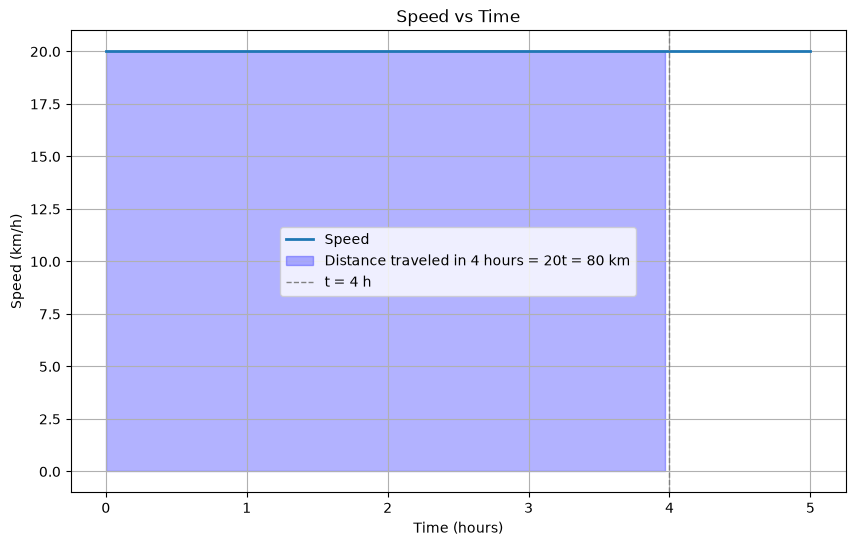

In [6]:
# Plot speed vs time with area under the line highlighted only up to t = 4
plt.figure(figsize=(10, 6))

t_stop = 4
mask = time <= t_stop

plt.plot(time, [speed] * len(time), linewidth=2, label='Speed')
plt.fill_between(time[mask], 0, speed, alpha=0.3, color='blue', label='Distance traveled in 4 hours = 20t = 80 km')
plt.axvline(t_stop, color='gray', linestyle='--', linewidth=1, label='t = 4 h')
plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time')
plt.legend()
plt.grid(True)
plt.show()

From the chart, we can also conclude that $f = 20t$ which is the area under the line which is also the formula for the first chart.

**Therefore, the slope of the distance-time graph gives the speed s. The area under the speed-time graph gives the distance f.**

**The area under the line give the function of the first chart f vs t.** 

**We can derived the speed from the distance function using the slope, thus speed is the derivative of distance function.**

**We can also calculate area of speed function to get the distance function. This is called integration.**

## When Speed Changes


What happen when speed varies? To make it simple, let's assume the speed changed twice.

Lets assume if we have only 2 speed block, if we travel with different speed for 2 hours:

- first hour : 20km/h
- second hour : 40km/h

What is the total distance traveled?

To get the answer, we need to calculate in 2 different block
- first block : $distance = 20 \times 1 = 20km$
- second block : $distance = 40 \times 1 = 40km$
- Total : $20+40 = 60km$


**Why we cannot use the speed to calculate the distance?**

We can use the speed to derived distance, but since the speed changes, we need to use the right speed to derived the right distance as shown above.

If we use 20km/h, we will have $distance = 20 \times 2 = 40km$. This is lower than the actual distance traveled. 

If we use 40km/h, we will have $distance = 40 \times 2 = 80km$. This is over the actual distance traveled. 

We may use the average speed to estimate the distance:
$$\text{average speed} = \frac{20+40}{2} = 30km/h $$
$$distance = 30 \times 2 = 60km$$

### Distance Function

time: [0, 1, 2]
distance: [0, 20, 60]
speed: [0, 20, 40]
time difference: [1, 1]


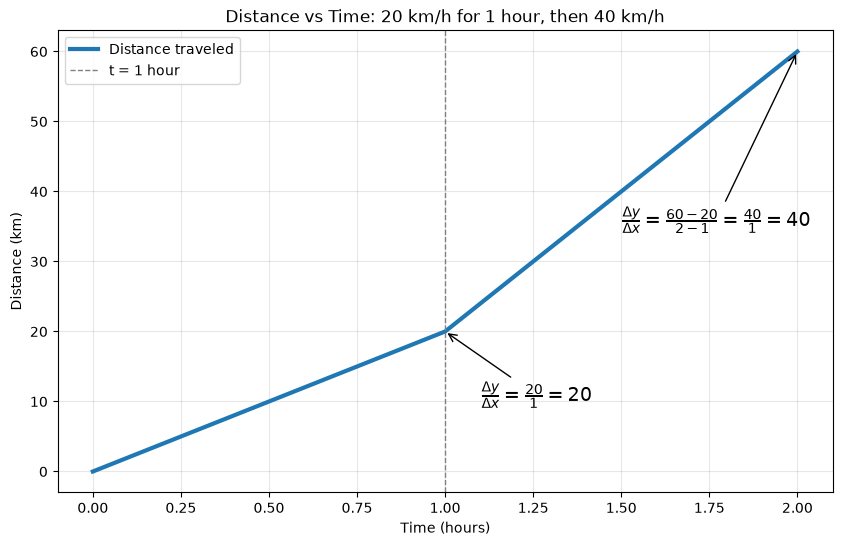

In [7]:
# Time range
time = [0, 1, 2]

# Distance values for each segment
# first hour: 20 km/h -> 20 km
# second hour: 40 km/h -> 40 km 
speed = [0, 20, 40]

# calculate time difference for each segment
time_diff = []
for i in range(len(time)-1):
    time_diff.append(time[i+1] - time[i])  
# should have [1,1] for the two segments

# Calculate cumulative distance
distance = []
cumulative_distance = 0
for i in range(1, len(speed)):
    cumulative_distance += speed[i] * time_diff[i-1]
    distance.append(cumulative_distance)
# should have [20, 60] for the two segments

# insert the initial distance (0 km) at the beginning of the distance list
distance.insert(0, 0)  # Now distance = [0, 20, 60]

# print all data for checks
print('time:', time)  # [0, 1, 2]
print('distance:', distance)  # [0, 20, 60]
print('speed:', speed)  # [0, 20, 40]
print('time difference:', time_diff)  # [1, 1]

# For numpy arrays for future calculations
# t = np.array(t)
# s = np.array(s)

# time_diff = np.diff(t)                  # [1, 1] — one fewer than t, no leading 0 needed
# distance = np.cumsum(s[1:] * time_diff) # [20, 60]
# distance = np.insert(distance, 0, 0)    # [0, 20, 60]


# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=3, color='tab:blue', label='Distance traveled')
# Add slope annotation for both line segments
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{20}{1} = 20$',
             xy=(1, 20), xytext=(1.1, 10),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')

plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{60-20}{2-1} = \frac{40}{1} = 40$',
             xy=(2, 60), xytext=(1.5, 35),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')

plt.axvline(1, color='gray', linestyle='--', linewidth=1, label='t = 1 hour')
plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time: 20 km/h for 1 hour, then 40 km/h')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


### Speed Function

The graph below shows that we can also get the area under the line for total distance traveled:

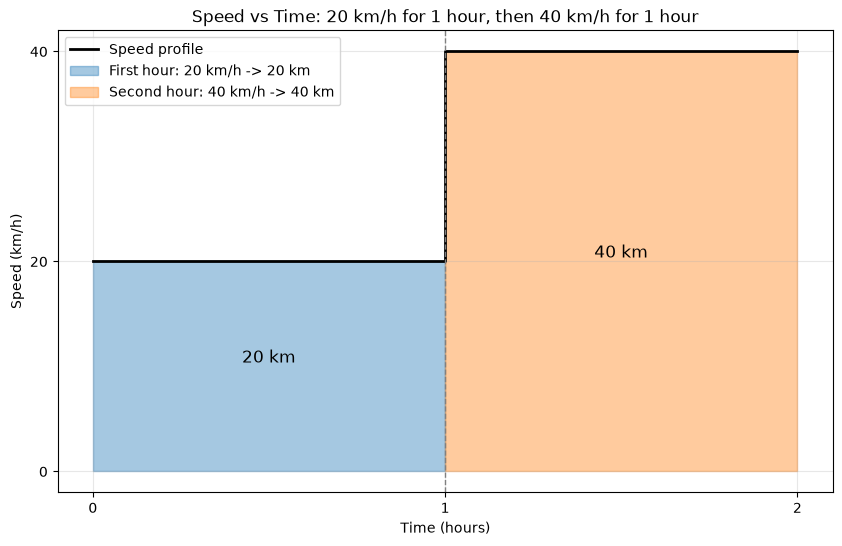

In [8]:
# Speed profile: first hour at 20 km/h, second hour at 40 km/h
x1 = np.array([0, 1, 1])
y1 = np.array([0, 0, 20])

x2 = np.array([1, 2, 2])
y2 = np.array([0, 0, 40])

plt.figure(figsize=(10, 6))

# Step line showing speed vs time
plt.step([0, 1, 2], [20, 40, 40], where='post', linewidth=2, color='black', label='Speed profile')

# Highlight the area under the first speed level
plt.fill_between([0, 1], 0, 20, step='post', alpha=0.4, color='tab:blue', label='First hour: 20 km/h -> 20 km')

# Highlight the area under the second speed level
plt.fill_between([1, 2], 0, 40, step='post', alpha=0.4, color='tab:orange', label='Second hour: 40 km/h -> 40 km')

# Vertical boundary between the two hours
plt.axvline(1, color='gray', linestyle='--', linewidth=1)

# Labels for the areas
plt.text(0.5, 10, '20 km', ha='center', va='bottom', fontsize=12)
plt.text(1.5, 20, '40 km', ha='center', va='bottom', fontsize=12)

plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time: 20 km/h for 1 hour, then 40 km/h for 1 hour')
plt.xticks([0, 1, 2])
plt.yticks([0, 20, 40])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

We still can get the slope and area from the 2 charts above in order to infer the speed and distance. In this case, we get the chunks.

For speed we plot different line and joined them together. For area under the curve, we just added all different area to get the total distance.

To get the formula we have:

Distance:
$$f(t) = \begin{cases}
  20t & 0 \le t \le 1 \\
  20 + 40 (t-1) & 1 \le t \le 2
\end{cases}$$


Speed:
$$s(t) = \begin{cases}
  20 & 0 \le t \le 1 \\
  40 & 1 \le t \le 2
\end{cases}$$

## When Speed Changes - 3x

If the speed changes 3 times

- speed = [0, 20, 40, 60]
- time = [0, 1, 2, 3]
- distance = [0, 20, 60, 120]

In [9]:
# Time range
time = [0, 1, 2, 3]

# Distance values for each segment
# first hour: 20 km/h -> 20 km
# second hour: 40 km/h -> 40 km 
# third hour: 60 km/h -> 60 km
speed = [0, 20, 40, 60]

# calculate time difference for each segment
time_diff = []
for i in range(len(time)-1):
    time_diff.append(time[i+1] - time[i])  
# should have [1,1,1] for the three segments

# Calculate cumulative distance
distance = []
cumulative_distance = 0
for i in range(1, len(speed)):
    cumulative_distance += speed[i] * time_diff[i-1]
    distance.append(cumulative_distance)
# should have [20, 60, 120] for the three segments

# insert the initial distance (0 km) at the beginning of the distance list
distance.insert(0, 0)  # Now distance = [0, 20, 60, 120]


# For numpy arrays for future calculations
time = np.array(time)
speed = np.array(speed)

time_diff = np.diff(time)        # [1, 1, 1] — one fewer than time, no leading 0 needed
distance = np.cumsum(speed[1:] * time_diff) # [20, 60, 120]
distance = np.insert(distance, 0, 0)    # [0, 20, 60, 120]


# print all data for checks
print('time:', time)  # [0, 1, 2, 3]
print('distance:', distance)  # [0, 20, 60, 120]
print('speed:', speed)  # [0, 20, 40, 60]
print('time difference:', time_diff)  # [1, 1, 1]

time: [0 1 2 3]
distance: [  0  20  60 120]
speed: [ 0 20 40 60]
time difference: [1 1 1]


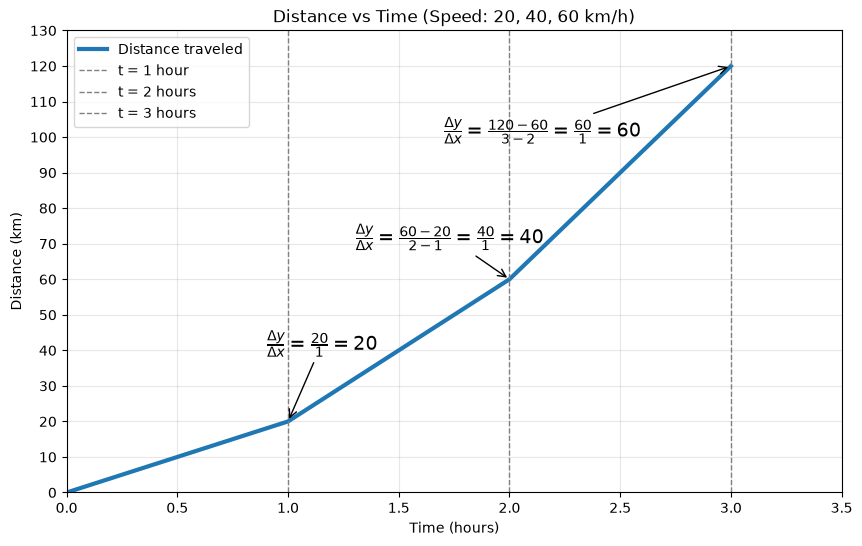

In [10]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=3, color='tab:blue', label='Distance traveled')

# Add slope annotation for both line segments
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{20}{1} = 20$',
             xy=(1, 20), xytext=(0.9, 40),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{60-20}{2-1} = \frac{40}{1} = 40$',
             xy=(2, 60), xytext=(1.3, 70),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{120-60}{3-2} = \frac{60}{1} = 60$',
             xy=(3, 120), xytext=(1.7, 100),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')

# Add vertical lines at t = 1, 2, and 3 hours
plt.axvline(1, color='gray', linestyle='--', linewidth=1, label='t = 1 hour')
plt.axvline(2, color='gray', linestyle='--', linewidth=1, label='t = 2 hours')
plt.axvline(3, color='gray', linestyle='--', linewidth=1, label='t = 3 hours')

# Set limits for x and y axes
plt.xlim(0, 3.5)
plt.ylim(0, 130)

# Set y ticks
plt.yticks(np.arange(0, 131, 10))

# Add labels and title
plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed: 20, 40, 60 km/h)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


As the speed changes, the slop varies, we need to calculate each slop to get the variation in speed.  

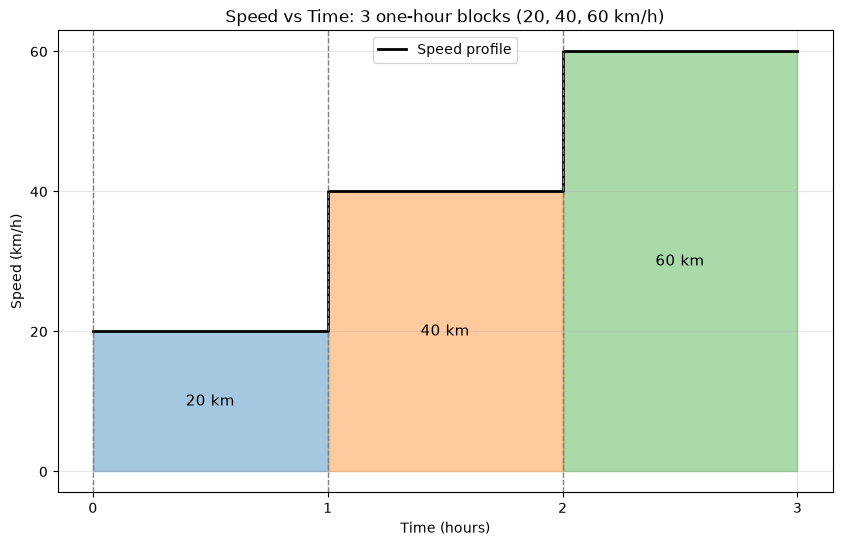

In [11]:
# 3 one-hour blocks, speed at the end of each block
speed = np.array([20, 40, 60])
time_edges = np.array([0, 1, 2, 3])   # hour boundaries

plt.figure(figsize=(10, 6))

# Step line showing speed vs time
plt.step(time_edges, np.append(speed, speed[-1]), where='post', linewidth=2, color='black', label='Speed profile')

colors = ['tab:blue', 'tab:orange', 'tab:green']
for i in range(len(speed)):
    plt.fill_between([time_edges[i], time_edges[i+1]], 0, speed[i], step='post', alpha=0.4, color=colors[i])
    plt.text((time_edges[i] + time_edges[i+1]) / 2, speed[i] / 2, f'{speed[i]} km',
             ha='center', va='center', fontsize=11)
    plt.axvline(time_edges[i], color='gray', linestyle='--', linewidth=1)

plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time: 3 one-hour blocks (20, 40, 60 km/h)')
plt.xticks(time_edges)
plt.yticks(list(speed) + [0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Similarly, to get the total distance we need to add the distance for each change in speed

## When Speed Changes - 5x

New let's complicate the problem by introducing 5 change in speed.

In [12]:
# 5 one-hour blocks, speed at the end of each block
speed = np.array([0, 2, 4, 6, 8, 10])
time = np.array([0, 1, 2, 3, 4, 5])  

time_diff = np.diff(time)        # [1, 1, 1, 1, 1] — one fewer than time, no leading 0 needed
distance = np.cumsum(speed[1:] * time_diff) # [2, 6, 12, 20, 30]
distance = np.insert(distance, 0, 0)    # [0, 2, 6, 12, 20, 30]


# print all data for checks
print('time:', time)  # [0, 1, 2, 3]
print('distance:', distance)  # [0, 2, 6, 12, 20, 30]
print('speed:', speed)  # [0, 2, 4, 6, 8, 10]
print('time difference:', time_diff)  # [1, 1, 1, 1, 1]



time: [0 1 2 3 4 5]
distance: [ 0  2  6 12 20 30]
speed: [ 0  2  4  6  8 10]
time difference: [1 1 1 1 1]


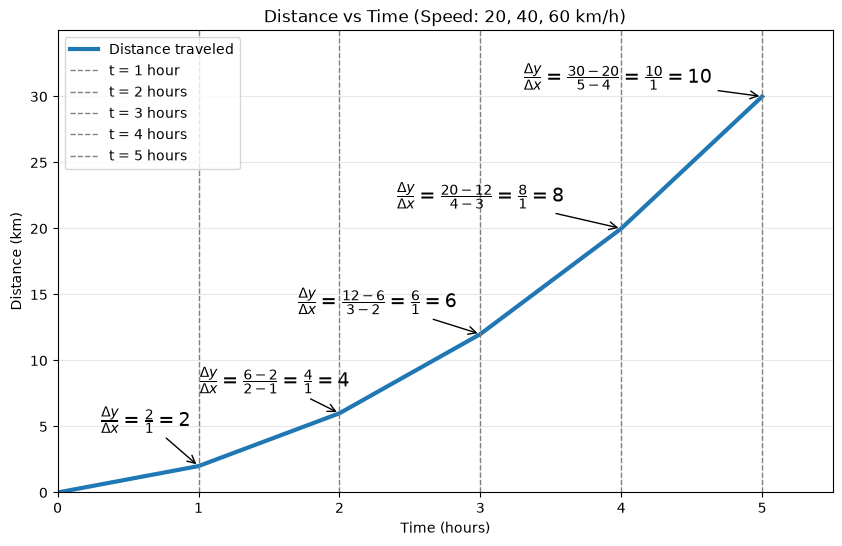

In [13]:
# Plot
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=3, color='tab:blue', label='Distance traveled')

# Add slope annotation for both line segments
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{2}{1} = 2$',
             xy=(1, 2), xytext=(0.3, 5),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{6-2}{2-1} = \frac{4}{1} = 4$',
             xy=(2, 6), xytext=(1, 8),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{12-6}{3-2} = \frac{6}{1} = 6$',
             xy=(3, 12), xytext=(1.7, 14),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{20-12}{4-3} = \frac{8}{1} = 8$',
             xy=(4, 20), xytext=(2.4, 22),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{30-20}{5-4} = \frac{10}{1} = 10$',
             xy=(5, 30), xytext=(3.3, 31),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=14, color='black')

# Add vertical lines at t = 1, 2, and 3 hours
plt.axvline(1, color='gray', linestyle='--', linewidth=1, label='t = 1 hour')
plt.axvline(2, color='gray', linestyle='--', linewidth=1, label='t = 2 hours')
plt.axvline(3, color='gray', linestyle='--', linewidth=1, label='t = 3 hours')
plt.axvline(4, color='gray', linestyle='--', linewidth=1, label='t = 4 hours')
plt.axvline(5, color='gray', linestyle='--', linewidth=1, label='t = 5 hours')

# Set limits for x and y axes
plt.xlim(0, 5.5)
plt.ylim(0, 35)

# Set y ticks
plt.yticks(np.arange(0, 35, 5))

# Add labels and title
plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed: 20, 40, 60 km/h)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

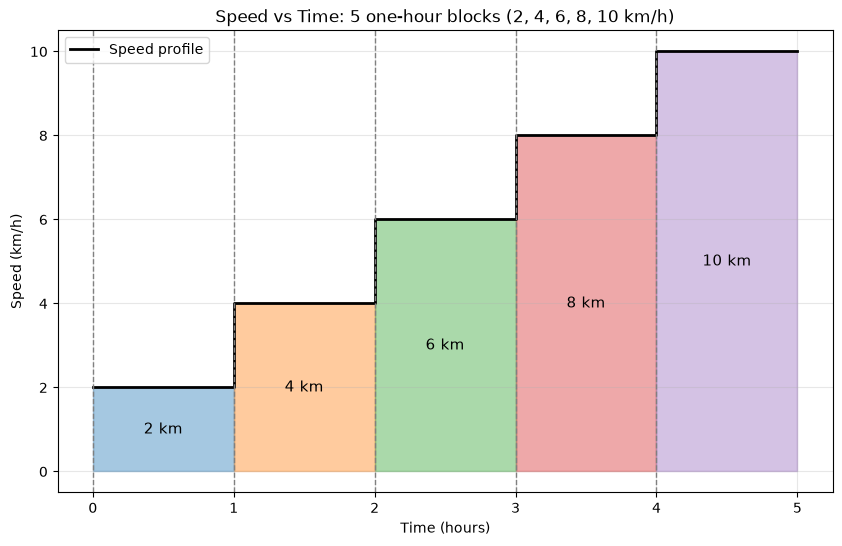

In [14]:
# 5 one-hour blocks, speed at the end of each block
speed = np.array([2, 4, 6, 8, 10])
time_edges = np.array([0, 1, 2, 3, 4, 5])   # hour boundaries

plt.figure(figsize=(10, 6))

# Step line showing speed vs time
plt.step(time_edges, np.append(speed, speed[-1]), where='post', linewidth=2, color='black', label='Speed profile')

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
for i in range(len(speed)):
    plt.fill_between([time_edges[i], time_edges[i+1]], 0, speed[i], step='post', alpha=0.4, color=colors[i])
    plt.text((time_edges[i] + time_edges[i+1]) / 2, speed[i] / 2, f'{speed[i]} km',
             ha='center', va='center', fontsize=11)
    plt.axvline(time_edges[i], color='gray', linestyle='--', linewidth=1)

plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time: 5 one-hour blocks (2, 4, 6, 8, 10 km/h)')
plt.xticks(time_edges)
plt.yticks(list(speed) + [0])
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## When Speed Changes Constantly 

Let's us try 10, 20, 50, 100 changes.

In [15]:
def plot_riemann_compare(n, t_max=5):
    """
    Show cumulative distance (left) and speed staircase (right) side by side,
    both approximating d = t^2 / v = 2t with n blocks.
    
    n: number of blocks
    t_max: upper limit of the time range
    
    returns: (total_area, distance) — final speed-sum area and full distance array
    """
    t_edges = np.linspace(0, t_max, n + 1)
    width = t_edges[1] - t_edges[0]

    # speed at the right edge of each block
    s = 2 * t_edges[1:]

    total_area = np.sum(s * width)
    distance = np.cumsum(s * width)
    distance = np.insert(distance, 0, 0)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # --- left: cumulative distance ---
    t_smooth = np.linspace(0, t_max, 200)
    ax1.plot(t_edges, distance, marker='o', linewidth=1.5,
              color='black', label=f'{n}-block cumulative distance')
    ax1.plot(t_smooth, t_smooth**2, color='tab:red', linewidth=2,
              linestyle='--', label='true d = t²')
    ax1.text(t_max / 4, t_max**2 * 0.7,
              f'block-sum distance ≈ {distance[-1]:.2f}\ntrue t² = {t_max**2}',
              fontsize=11, ha='center',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax1.set_xlabel('Time (hours)')
    ax1.set_ylabel('Distance (km)')
    ax1.set_title(f'Distance vs Time ({n} blocks)')
    ax1.grid(True, alpha=0.3)
    ax1.legend()

    # --- right: speed staircase ---
    ax2.step(t_edges, np.append(s, s[-1]), where='post', linewidth=1.5,
              color='black', label=f'{n}-block staircase (v = 2t sampled)')
    ax2.fill_between(t_edges, np.append(s, s[-1]), step='post',
                      alpha=0.3, color='tab:blue')
    ax2.plot(t_smooth, 2 * t_smooth, color='tab:red', linewidth=2,
              linestyle='--', label='true v = 2t')
    ax2.text(t_max / 2, 2, f'staircase area ≈ {total_area:.2f}\ntrue t² = {t_max**2}',
              fontsize=11, ha='center',
              bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax2.set_xlabel('Time (hours)')
    ax2.set_ylabel('Speed (km/h)')
    ax2.set_title(f'Speed vs Time ({n} blocks)')
    ax2.grid(True, alpha=0.3)
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return total_area, distance

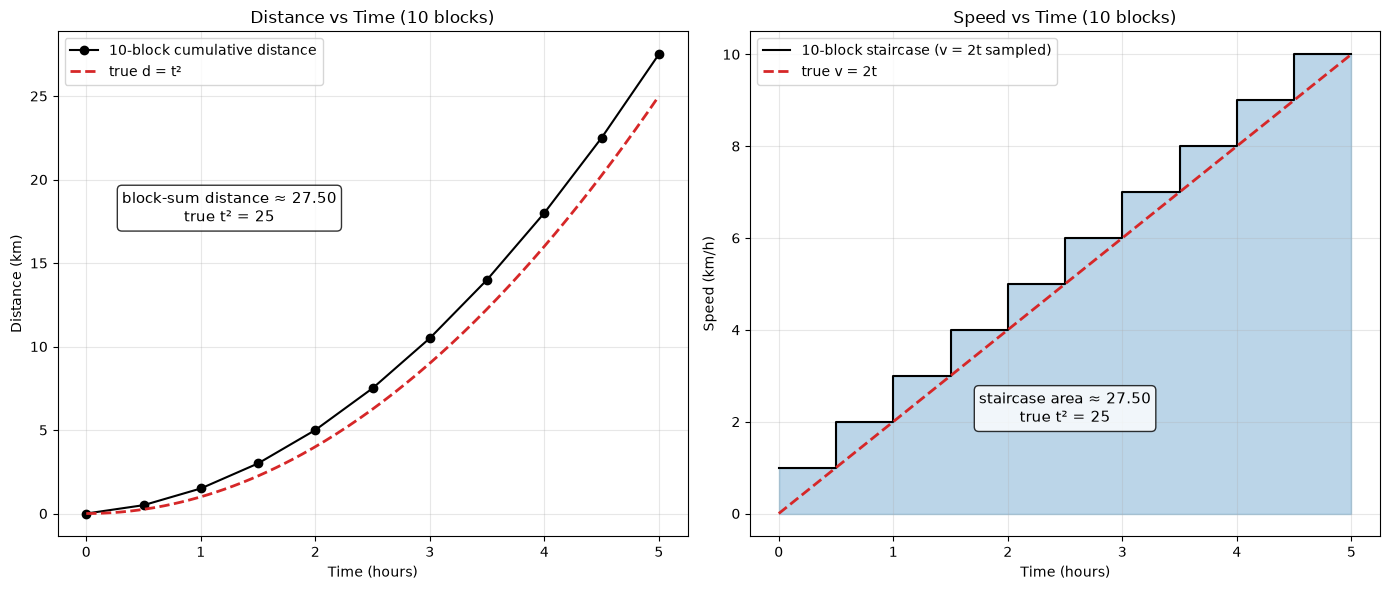

(np.float64(27.5),
 array([ 0. ,  0.5,  1.5,  3. ,  5. ,  7.5, 10.5, 14. , 18. , 22.5, 27.5]))

In [16]:
# Plot for 10 changes
plot_riemann_compare(10, t_max=5)

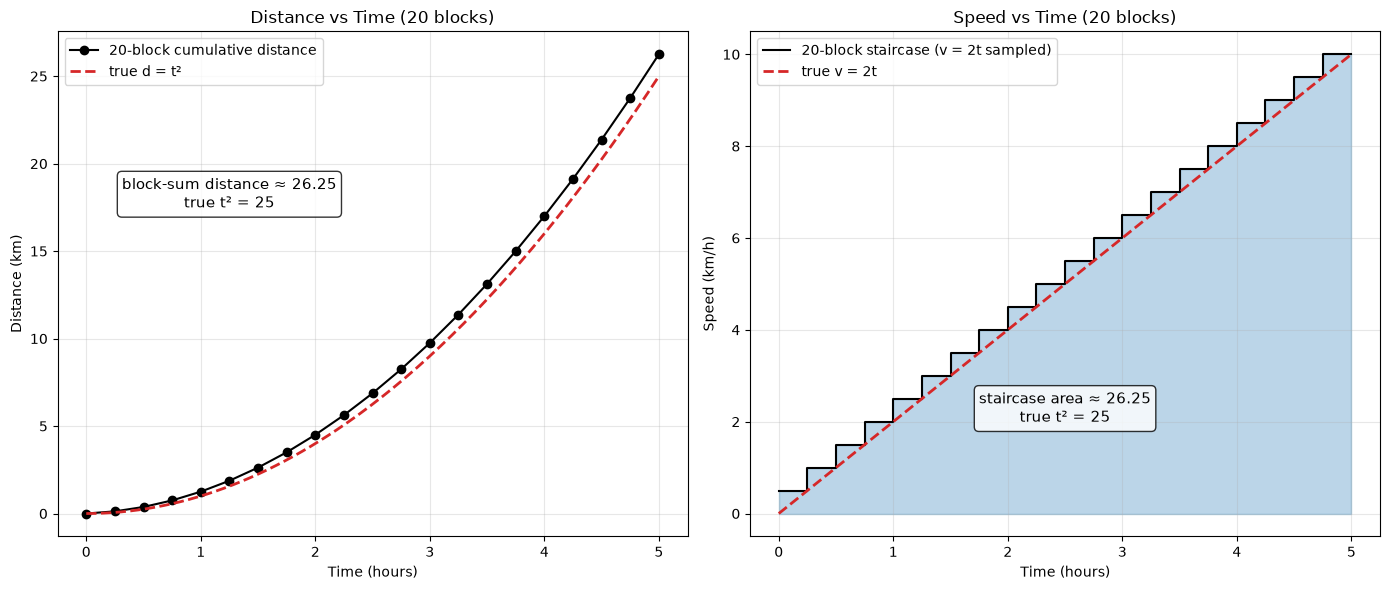

(np.float64(26.25),
 array([ 0.   ,  0.125,  0.375,  0.75 ,  1.25 ,  1.875,  2.625,  3.5  ,
         4.5  ,  5.625,  6.875,  8.25 ,  9.75 , 11.375, 13.125, 15.   ,
        17.   , 19.125, 21.375, 23.75 , 26.25 ]))

In [17]:
# 20 changes
plot_riemann_compare(20, t_max=5)

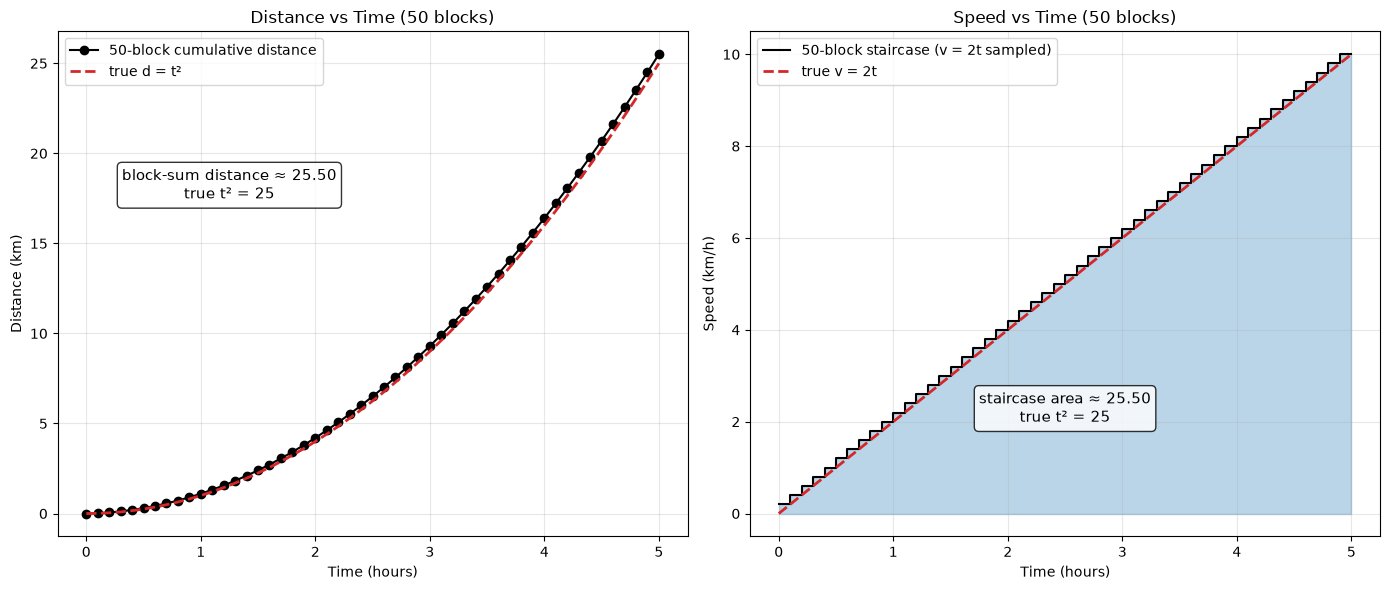

(np.float64(25.500000000000004),
 array([0.000e+00, 2.000e-02, 6.000e-02, 1.200e-01, 2.000e-01, 3.000e-01,
        4.200e-01, 5.600e-01, 7.200e-01, 9.000e-01, 1.100e+00, 1.320e+00,
        1.560e+00, 1.820e+00, 2.100e+00, 2.400e+00, 2.720e+00, 3.060e+00,
        3.420e+00, 3.800e+00, 4.200e+00, 4.620e+00, 5.060e+00, 5.520e+00,
        6.000e+00, 6.500e+00, 7.020e+00, 7.560e+00, 8.120e+00, 8.700e+00,
        9.300e+00, 9.920e+00, 1.056e+01, 1.122e+01, 1.190e+01, 1.260e+01,
        1.332e+01, 1.406e+01, 1.482e+01, 1.560e+01, 1.640e+01, 1.722e+01,
        1.806e+01, 1.892e+01, 1.980e+01, 2.070e+01, 2.162e+01, 2.256e+01,
        2.352e+01, 2.450e+01, 2.550e+01]))

In [18]:
# plot for 50 changes
plot_riemann_compare(50, t_max=5)

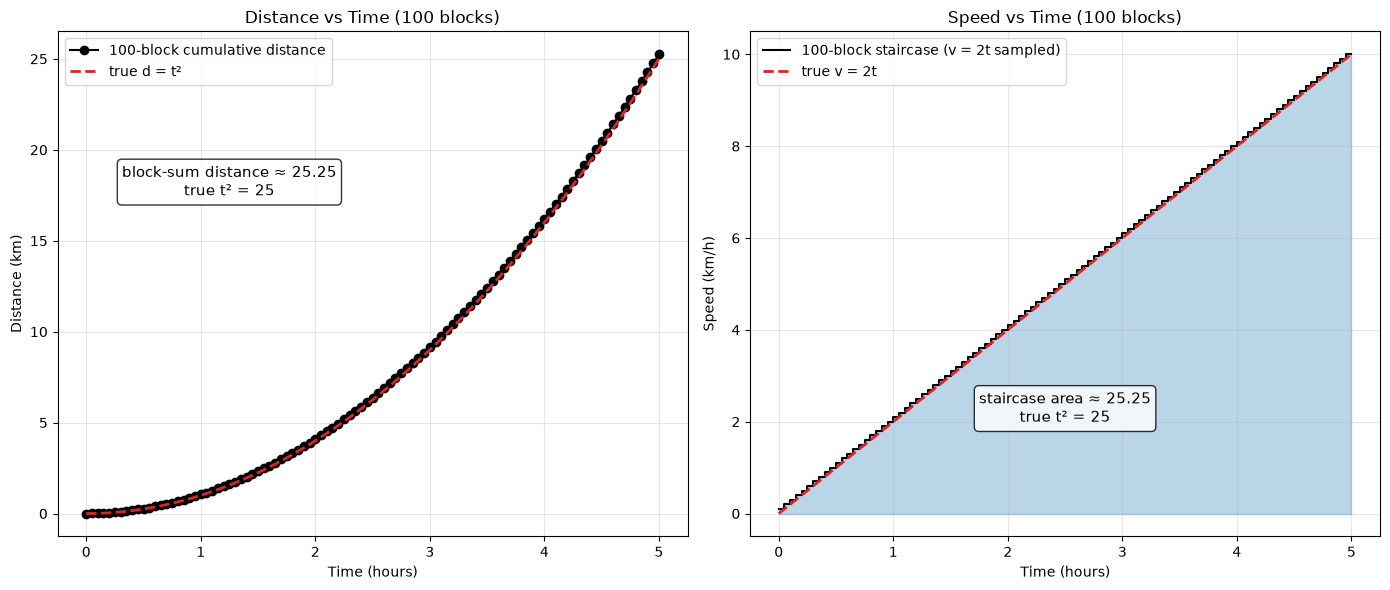

(np.float64(25.25),
 array([0.0000e+00, 5.0000e-03, 1.5000e-02, 3.0000e-02, 5.0000e-02,
        7.5000e-02, 1.0500e-01, 1.4000e-01, 1.8000e-01, 2.2500e-01,
        2.7500e-01, 3.3000e-01, 3.9000e-01, 4.5500e-01, 5.2500e-01,
        6.0000e-01, 6.8000e-01, 7.6500e-01, 8.5500e-01, 9.5000e-01,
        1.0500e+00, 1.1550e+00, 1.2650e+00, 1.3800e+00, 1.5000e+00,
        1.6250e+00, 1.7550e+00, 1.8900e+00, 2.0300e+00, 2.1750e+00,
        2.3250e+00, 2.4800e+00, 2.6400e+00, 2.8050e+00, 2.9750e+00,
        3.1500e+00, 3.3300e+00, 3.5150e+00, 3.7050e+00, 3.9000e+00,
        4.1000e+00, 4.3050e+00, 4.5150e+00, 4.7300e+00, 4.9500e+00,
        5.1750e+00, 5.4050e+00, 5.6400e+00, 5.8800e+00, 6.1250e+00,
        6.3750e+00, 6.6300e+00, 6.8900e+00, 7.1550e+00, 7.4250e+00,
        7.7000e+00, 7.9800e+00, 8.2650e+00, 8.5550e+00, 8.8500e+00,
        9.1500e+00, 9.4550e+00, 9.7650e+00, 1.0080e+01, 1.0400e+01,
        1.0725e+01, 1.1055e+01, 1.1390e+01, 1.1730e+01, 1.2075e+01,
        1.2425e+01, 1.2780e+

In [19]:
# plot for 100 changes
plot_riemann_compare(100, t_max=5)

**As you can see the progress, if there are more and more changes, gradually we converge to a curve function in distance vs time graph. For speed vs time graph, it convert from staircase chart to a straight line graph.** 

## Relation Between Speed and Distance Graph

What happen if the speed changes constantly. Lets assume the acceleration of a car, the speed increase by 2t.

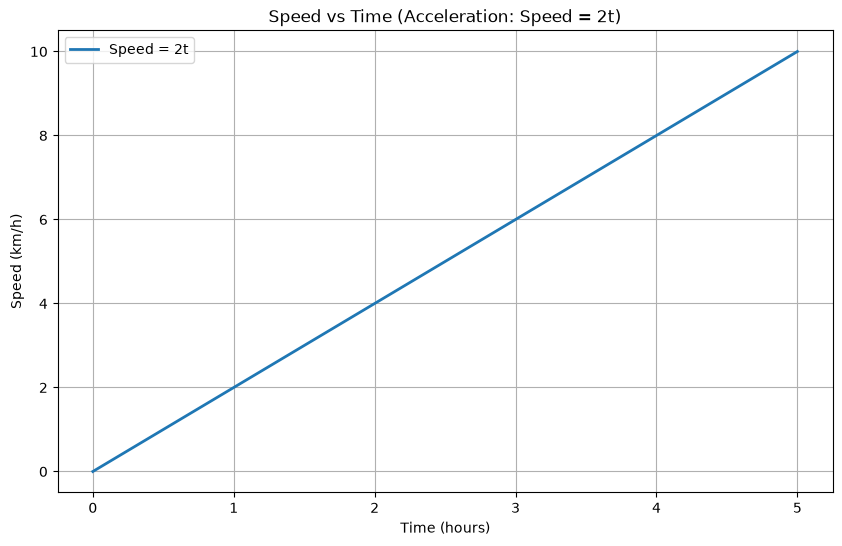

In [20]:
# Plot speed vs time with speed = 2*t
time = np.linspace(0, 5, 30)
plt.figure(figsize=(10, 6))
speed_2x = 2 * time
plt.plot(time, speed_2x, linewidth=2, label='Speed = 2t')
plt.xlabel('Time (hours)')
plt.ylabel('Speed (km/h)')
plt.title('Speed vs Time (Acceleration: Speed = 2t)')
plt.legend()
plt.grid(True)
plt.show()

The chart above is $s = 2t$. Since we have the speed chart above and we know that the area under the chart, we can get the function of distance vs t.

$$s = 2t$$

If $t = 3$, then the area under the chart is

$$area = \frac{speed \times time}{2} = \frac{6 \times 3}{2} = 9$$

If $t = 4$, then the area under the chart is

$$area = \frac{speed \times time}{2} = \frac{8 \times 4}{2} = 16$$

If $t = 5$, then the area under the chart is

$$area = \frac{speed \times time}{2} = \frac{10 \times 5}{2} = 25$$


In [21]:
time = np.array([0, 1, 2, 3, 4, 5])
speed = 2 * time
area = 0.5 * speed * time  # Area under the speed-time graph (distance traveled)
df = pd.DataFrame({'Time (hours)': time, 'Speed (km/h)': speed, 'Distance (Area)': area})
print(df)

   Time (hours)  Speed (km/h)  Distance (Area)
0             0             0              0.0
1             1             2              1.0
2             2             4              4.0
3             3             6              9.0
4             4             8             16.0
5             5            10             25.0


To generalized above:

$$area = \frac{speed \times time}{2} = \frac{s \times t}{2}$$

Since 

$$s = 2t$$

$$area = \frac{s \times t}{2} = \frac{2t \times t}{2}$$

Therefore,

$$area = distance = \frac{2t^2}{2}$$

$$area = distance = t^2$$

We can compute distance as follows:

$$f = t^2$$

If we applied $d = t^2$ to the dataframe above. We have

In [22]:
formula = time ** 2  # Distance traveled with speed = t^2
df.insert(3, 'Distance (d = t^2)', formula)
print(df)

   Time (hours)  Speed (km/h)  Distance (Area)  Distance (d = t^2)
0             0             0              0.0                   0
1             1             2              1.0                   1
2             2             4              4.0                   4
3             3             6              9.0                   9
4             4             8             16.0                  16
5             5            10             25.0                  25


The above proved that the derived distance function is $f = t^2$

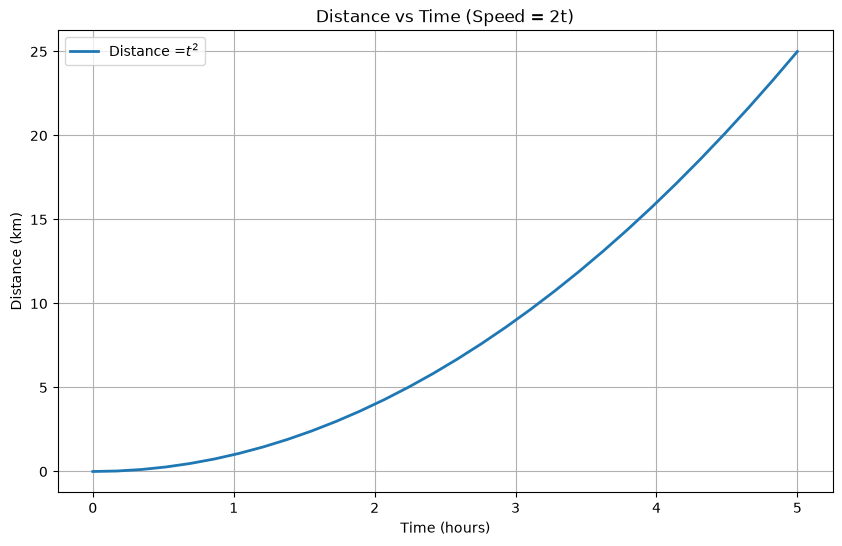

In [23]:
# Plot distance vs t
time = np.linspace(0, 5, 30)
distance = time ** 2  # Distance traveled with speed = t^2
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=2, label='Distance =$t^2$')
plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed = 2t)')
plt.legend()
plt.grid(True)
plt.show()

### Why $f = t^2$

A lot people ask if $s = 2t$ and $f = st$, then $f$ should be 

$$f = st = 2t \times t = 2t^2$$

When we talk about distance, distance refers to total distance traveled. At a constant speed, we can see the table below that the difference in distance is actually the same as speed. 

In [24]:
t = np.array([0, 1, 2, 3, 4, 5])
s = 60
f = s * t

In [25]:
df_constant = pd.DataFrame({'Time (hours)': t, 'Speed (km/h)': s, 'Distance (f = 60t)': f})
print(df_constant)

   Time (hours)  Speed (km/h)  Distance (f = 60t)
0             0            60                   0
1             1            60                  60
2             2            60                 120
3             3            60                 180
4             4            60                 240
5             5            60                 300


In [26]:
# Calculate the difference between consecutive distance values
df_constant['Distance Difference (km)'] = df_constant['Distance (f = 60t)'].diff()
print(df_constant)

   Time (hours)  Speed (km/h)  Distance (f = 60t)  Distance Difference (km)
0             0            60                   0                       NaN
1             1            60                  60                      60.0
2             2            60                 120                      60.0
3             3            60                 180                      60.0
4             4            60                 240                      60.0
5             5            60                 300                      60.0


For varied speed, we need to compute the speed for each change in speed and then add them up. In our previous example where $s = 2t$, we cannot determine the speed as it is increase continuously. Thus the best method is to get the area under the speed curve/line as shown in the example above.

This is also known as integration in Calculus.

### Generalize Formula


We can generalized that: 
If 
$$s = 2t$$
Then
$$f = \frac{s \times t}{2}$$
$$f = \frac{2t \times t}{2} = \frac{2t^2}{2} = t^2$$

When $s = 3t$:

$$f = \frac{s \times t}{2}$$
$$s = 3t$$
$$f = \frac{3t \times t}{2} = \frac{3t^2}{2}$$


Let's generalized further by letting 2 be replace by any constant (a):

$$s = at$$
$$f = \frac{at \times t}{2} = \frac{at^2}{2}$$
$$\frac{df}{dt} = slope = speed = at$$

## Getting Speed

If we have $f = t^2$, but we do not have the function of the speed. How can we calculate the slope of $f = t^2$

We can use the concept of calculus to determine the slope at one point. 

$$f = t^2$$

Since this is the distance-time graph, we can get the slope. The slope is $\frac{\Delta y}{\Delta x}$

$$\frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$


Delta x: 2, Delta y: 12, Slope: 6.0


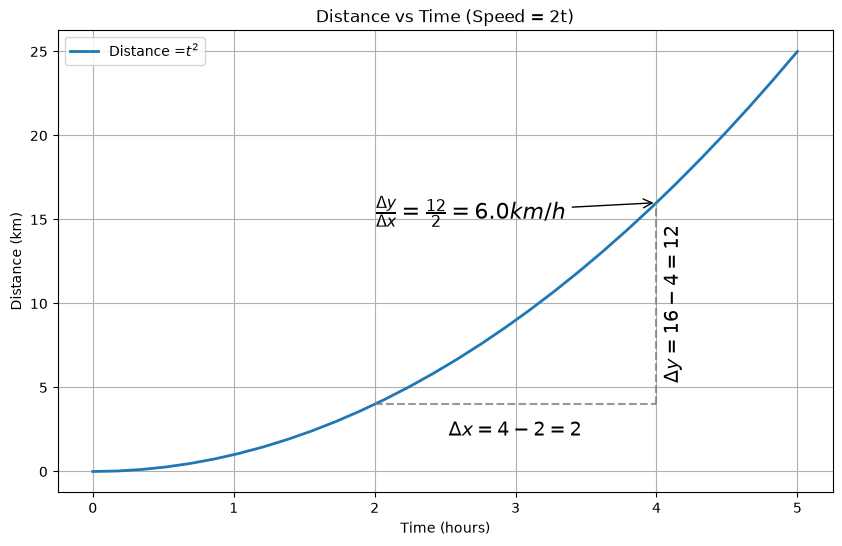

In [27]:
# Time in hours
time = np.linspace(0, 5, 30)
distance = time ** 2  # Distance traveled with speed = t^2

# Plot distance vs time
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=2, label='Distance =$t^2$')

# Highlight the slope as change in y over change in x
x1, x2 = 2, 4
y1, y2 = x1**2, x2**2
dx = x2 - x1
dy = y2 - y1
print(f"Delta x: {dx}, Delta y: {dy}, Slope: {dy/dx}")

plt.hlines(y1, x1, x2, colors='gray', linestyles='--', alpha=0.8)
plt.vlines(x2, y1, y2, colors='gray', linestyles='--', alpha=0.8)

plt.text((x1 + x2) / 2, y1 - 1, r'$\Delta x = 4-2=2$', ha='center', va='top', fontsize=14)
plt.text(x2 + 0.12, (y1 + y2) / 2, r'$\Delta y = 16-4=12$', rotation=90, ha='center', va='center', fontsize=14)
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{' + str(dy) + '}{' + str(dx) + '} = ' + str(dy/dx) + 'km/h$',
             xy=(x2, y2), xytext=(2, 15),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=16, color='black')

plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed = 2t)')
plt.legend()
plt.grid(True)
plt.show()


If we squeeze the change of y and change of x to very small.

x1: 3.9, x2: 4.0, y1: 15.2, y2: 16.0
Delta x: 0.1, Delta y: 0.8, Slope: 8.0


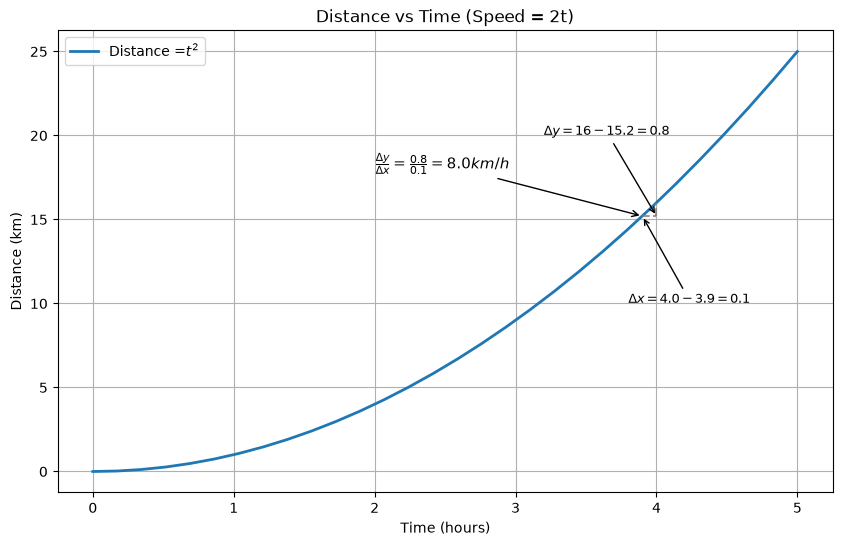

In [28]:
# Time in hours
time = np.linspace(0, 5, 30)
distance = time ** 2  # Distance traveled with speed = t^2

# Plot distance vs time
plt.figure(figsize=(10, 6))
plt.plot(time, distance, linewidth=2, label='Distance =$t^2$')

# Highlight the slope as change in y over change in x
x1, x2 = 3.9, 4.0
y1, y2 = round(x1**2,1), round(x2**2,1)
dx = round(x2 - x1, 1)
dy = round(y2 - y1, 1)
print(f"x1: {x1}, x2: {x2}, y1: {y1}, y2: {y2}")
print(f"Delta x: {dx}, Delta y: {dy}, Slope: {dy/dx}")

plt.hlines(y1, x1, x2, colors='gray', linestyles='--', alpha=0.8)
plt.vlines(x2, y1, y2, colors='gray', linestyles='--', alpha=0.8)

plt.annotate(r'$\Delta x = 4.0-3.9=0.1$',
             xy=(x1, y1), xytext=(3.8, 10),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='black')
plt.annotate(r'$\Delta y = 16-15.2=0.8$',
             xy=(x2, y1), xytext=(3.2, 20),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=9, color='black')
plt.annotate(r'$\frac{\Delta y}{\Delta x} = \frac{' + str(dy) + '}{' + str(dx) + '} = ' + str(dy/dx) + 'km/h$',
             xy=(x1, y1), xytext=(2, 18),
             arrowprops=dict(arrowstyle='->', color='black'),
             fontsize=11, color='black')

plt.xlabel('Time (hours)')
plt.ylabel('Distance (km)')
plt.title('Distance vs Time (Speed = 2t)')
plt.legend()
plt.grid(True)
plt.show()

Based on the 2 graph above, we can see that as we narrow the changes, we can get the speed at a particular time. Using formula, the working is as follows:

$$f = t^2$$

$$\frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$

We can define $x2$, $y_1$ and $y2$ as:
$$x_2 = x_1 + \Delta x$$
$$y_1 = f(x_1) = x_1^2$$
$$y_2 = f(x_2) = (x_1 + \Delta x)^2$$

Applying the slope formula:
$$\frac{\Delta y}{\Delta x} = \frac{y_2 - y_1}{x_2 - x_1}$$
$$\frac{\Delta y}{\Delta x} = \frac{(x_1 + \Delta x)^2 - x_1^2}{(x_1 + \Delta x) - x_1} = \frac{(x_1 + \Delta x)^2 - x_1^2}{\Delta x}$$
$$\frac{\Delta y}{\Delta x} = \frac{x_1^2 + 2x_1\Delta x + \Delta x^2 - x_1^2}{\Delta x}$$
Let's simplified the numerator first and then divide by the denominator
$$\frac{\Delta y}{\Delta x} = \frac{2x_1\Delta x + \Delta x^2}{\Delta x}$$
$$\frac{\Delta y}{\Delta x} = 2x_1 + \Delta x = 2x + \Delta x$$

Using the example in the previous chart, we have $\Delta x = 0.1$ therefore,

$$\frac{\Delta y}{\Delta x} = 2x + 0.1$$

What happen if we squeeze the $\Delta x$ further? Lets say $0.000000001$, we can effectively remove $\Delta x$

$$\frac{dy}{dx} = \lim_{\Delta x \rightarrow 0}(2x + \Delta x) = 2x$$

The above is the same as the speed function:

$$s = 2t = 2x$$

> $\Delta$ = finite, $\frac{d}{dx}$ = with limit

## END